In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import statsmodels.api as sm
from sklearn.model_selection import StratifiedKFold, cross_validate

df=pd.read_csv("/Users/shreyaparthiban/dedup_uci_diabetes.csv")

In [7]:
#Group high level of detail features
df = df[~df['discharge_disposition_desc'].str.contains(
    'Expired|Hospice', case=False, na=False
)]
def group_discharge(x):
    if pd.isnull(x):
        return 'Other'
    
    x = x.lower()
    
    if 'home' in x and 'health' not in x:
        return 'Home'
    elif 'home health' in x:
        return 'Home_Health'
    elif 'snf' in x or 'nursing' in x or 'icf' in x:
        return 'Skilled_Nursing'
    elif 'rehab' in x:
        return 'Rehab'
    elif 'short term hospital' in x:
        return 'Short_Term_Hospital'
    elif 'long term care' in x:
        return 'Long_Term_Care'
    elif 'psychiatric' in x:
        return 'Psych'
    elif 'left ama' in x:
        return 'AMA'
    else:
        return 'Other'

df['discharge_group'] = df['discharge_disposition_desc'].apply(group_discharge)
df['discharge_group'].value_counts()

discharge_group
Home                   44390
Skilled_Nursing         9350
Home_Health             8289
Other                   4236
Short_Term_Hospital     1539
Rehab                   1410
AMA                      409
Long_Term_Care           260
Psych                     90
Name: count, dtype: int64

In [8]:
#drop diag codes 
df.drop(columns=['diag_1','diag_2', 'diag_3'],inplace=True)

In [9]:
#Feature setup
y = df['readmitted_<30']

# Numerical variables
num_vars = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'cci'
]

#Categorical variables
cat_vars = [
    'gender',
    'race',
    'admission_type_desc',
    'discharge_group'
]

df_cat = pd.get_dummies(df[cat_vars], drop_first=True)

# Ordinal variable

df['age_num'] = df['age'].str.extract(r'(\d+)').astype(float)

# Final features
X = pd.concat([df[num_vars], df_cat, df[['age_num']]], axis=1)
X = X.fillna(0)
X = X.astype(float)

In [ ]:
print(df.shape)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Selection log model
X_train_sm = sm.add_constant(X_train)

logit_model = sm.Logit(y_train, X_train_sm).fit()
print(logit_model.summary())

# significant vars
pvals = logit_model.pvalues
significant_vars = pvals[pvals < 0.05].index.tolist()
significant_vars = [v for v in significant_vars if v != 'const']

print("\nSignificant Variables:")
print(significant_vars)


# Statsmodels
X_train_sm_sig = sm.add_constant(X_train[significant_vars])
X_test_sm_sig = sm.add_constant(X_test[significant_vars])

final_model = sm.Logit(y_train, X_train_sm_sig).fit()
print(final_model.summary())

# Prediction log model

X_train_ml = X_train[significant_vars]
X_test_ml = X_test[significant_vars]

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_ml, y_train)

# Predictions
y_prob = log_reg.predict_proba(X_test_ml)[:, 1]
y_pred = log_reg.predict(X_test_ml)

         Current function value: 0.290316
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:         readmitted_<30   No. Observations:                55978
Model:                          Logit   Df Residuals:                    55947
Method:                           MLE   Df Model:                           30
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                 0.03829
Time:                        07:13:45   Log-Likelihood:                -16251.
converged:                      False   LL-Null:                       -16898.
Covariance Type:            nonrobust   LLR p-value:                2.568e-253
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -3.2861      0.218    -15.100      0.000      -3.713   

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:         readmitted_<30   No. Observations:                55978
Model:                          Logit   Df Residuals:                    55967
Method:                           MLE   Df Model:                           10
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                 0.03138
Time:                        07:13:45   Log-Likelihood:                -16368.
converged:                       True   LL-Null:                       -16898.
Covariance Type:            nonrobust   LLR p-value:                1.625e-221
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -3.6295      0.084    -43.015      0.000      -3.795      -3.464
time_in_hospital                        0.0447      0.00


Model Performance
Accuracy: 0.661
F1 Score: 0.205
AUC: 0.624

Confusion Matrix:
[[8636 4104]
 [ 644  611]]


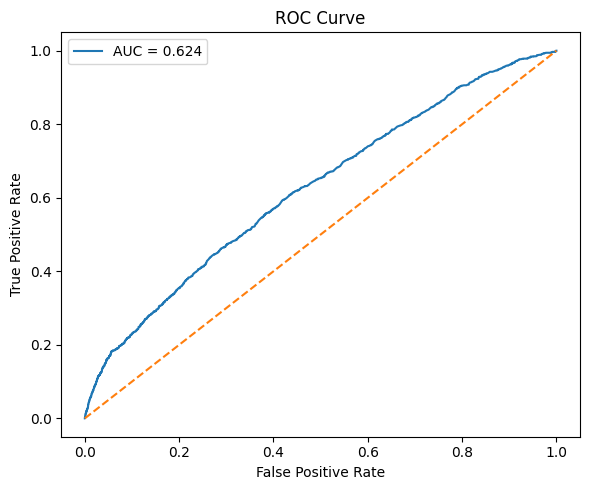

In [11]:
#Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\nModel Performance")
print("Accuracy:", round(accuracy, 3))
print("F1 Score:", round(f1, 3))
print("AUC:", round(auc, 3))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
#ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()


Random Forest (Default)
Accuracy: 0.91
F1 Score: 0.008
AUC: 0.6

Confusion Matrix:
[[12733     7]
 [ 1250     5]]

Feature Importance:
                                Feature  Importance
1                    num_lab_procedures    0.190044
3                       num_medications    0.161191
0                      time_in_hospital    0.103889
29                              age_num    0.079995
7                      number_diagnoses    0.076871
2                        num_procedures    0.076015
8                                   cci    0.068008
4                     number_outpatient    0.030743
9                           gender_Male    0.029476
6                      number_inpatient    0.027351
12                       race_Caucasian    0.024348
15        admission_type_desc_Emergency    0.023162
5                      number_emergency    0.018250
21                 discharge_group_Home    0.018157
20           admission_type_desc_Urgent    0.017910
26                discharge_grou

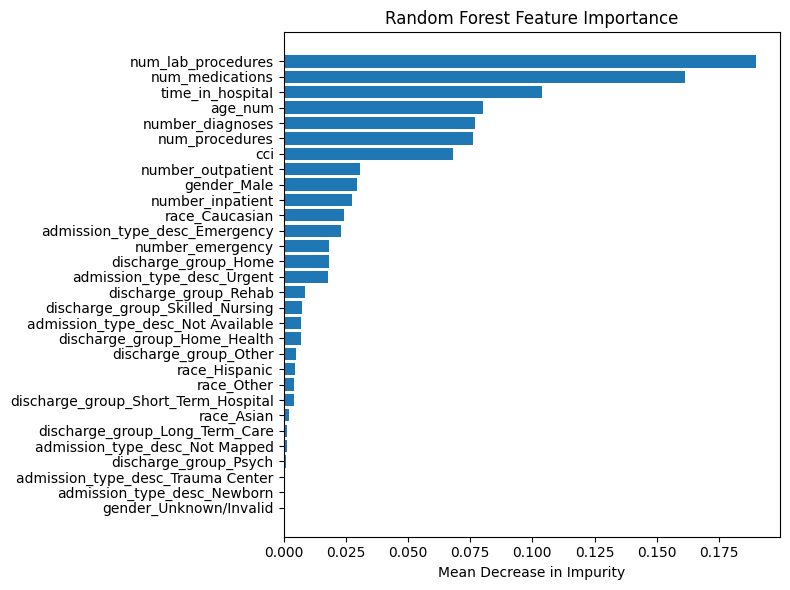

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check i


Best Parameters: {'class_weight': None, 'max_features': 'log2', 'min_samples_leaf': 5, 'n_estimators': 400}
Best CV AUC: 0.642


In [12]:
#Random forest

np.random.seed(123)

# 1. Train/Test Split on all features
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Default Random Forest
rf1 = RandomForestClassifier(random_state=123, class_weight='balanced')
rf1.fit(X_train_rf, y_train_rf)

# Predictions
rf_pred = rf1.predict(X_test_rf)
rf_prob = rf1.predict_proba(X_test_rf)[:, 1]

# Metrics
print("\nRandom Forest (Default)")
print("Accuracy:", round(accuracy_score(y_test_rf, rf_pred), 3))
print("F1 Score:", round(f1_score(y_test_rf, rf_pred), 3))
print("AUC:", round(roc_auc_score(y_test_rf, rf_prob), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_rf, rf_pred))

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_train_rf.columns,
    'Importance': rf1.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

# Plot importance
plt.figure(figsize=(8,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Mean Decrease in Impurity')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

#Tuning w grid search
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': [None, 'balanced']
}

rf = RandomForestClassifier(random_state=123)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_rf, y_train_rf)

print("\nBest Parameters:", grid_search.best_params_)
print("Best CV AUC:", round(grid_search.best_score_, 3))
# Evaluate new model
best_rf = grid_search.best_estimator_

rf_pred2 = best_rf.predict(X_test_rf)
rf_prob2 = best_rf.predict_proba(X_test_rf)[:, 1]




Random Forest (Tuned)
Accuracy: 0.91
F1 Score: 0.0
AUC: 0.637

Confusion Matrix:
[[12740     0]
 [ 1255     0]]

Feature Importance:
                                Feature    Importance
1                    num_lab_procedures  1.785846e-01
3                       num_medications  1.486213e-01
0                      time_in_hospital  9.839547e-02
29                              age_num  7.410257e-02
2                        num_procedures  7.068947e-02
7                      number_diagnoses  6.920682e-02
8                                   cci  6.648489e-02
6                      number_inpatient  5.548637e-02
9                           gender_Male  2.844374e-02
26                discharge_group_Rehab  2.747802e-02
21                 discharge_group_Home  2.668131e-02
4                     number_outpatient  2.615412e-02
15        admission_type_desc_Emergency  2.375765e-02
5                      number_emergency  1.921749e-02
12                       race_Caucasian  1.914987e-02
20

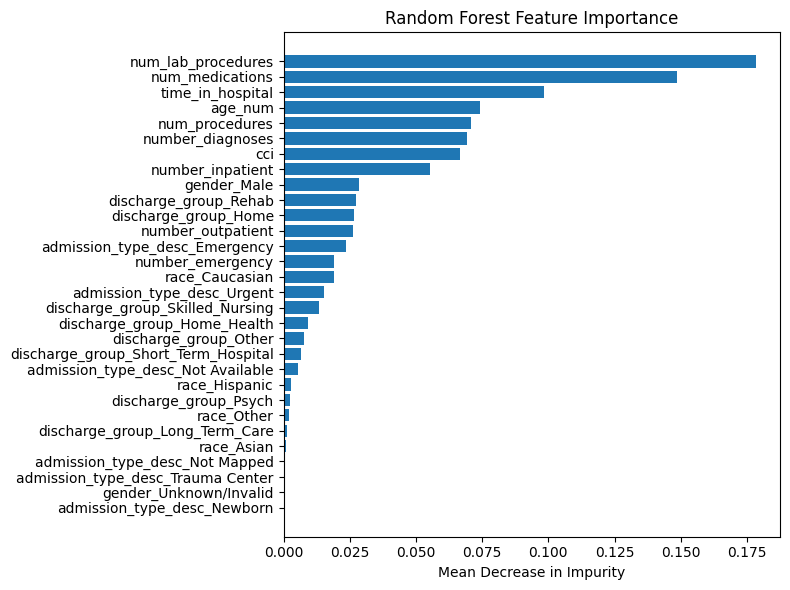

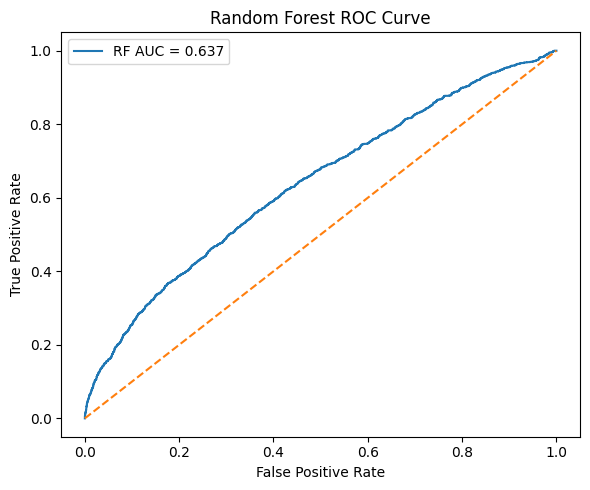

In [20]:
print("\nRandom Forest (Tuned)")
print("Accuracy:", round(accuracy_score(y_test_rf, rf_pred2), 3))
print("F1 Score:", round(f1_score(y_test_rf, rf_pred2), 3))
print("AUC:", round(roc_auc_score(y_test_rf, rf_prob2), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_rf, rf_pred2))

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_train_rf.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(8,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Mean Decrease in Impurity')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()
#ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, rf_prob2)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f'RF AUC = {roc_auc_score(y_test_rf, rf_prob2):.3f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
importance_df['Cumulative'] = importance_df['Importance'].cumsum()

top_features = importance_df[importance_df['Cumulative'] <= 0.85]

/var/folders/kj/xf1gwqjj3xs_xwlpb70458h40000gn/T/ipykernel_97938/2337939814.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(importance_df['Feature'], rotation=90)


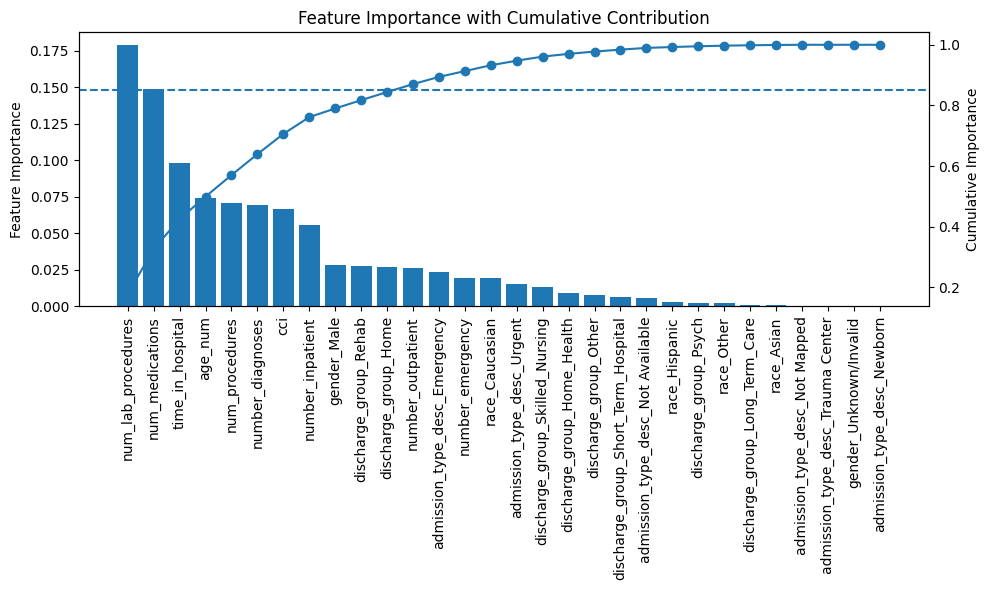

In [24]:

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar chart (feature importance)
ax1.bar(importance_df['Feature'],importance_df['Importance'])
ax1.set_ylabel('Feature Importance')
ax1.set_xticklabels(importance_df['Feature'], rotation=90)

# Second axis for cumulative line
ax2 = ax1.twinx()
ax2.plot(importance_df['Feature'], importance_df['Cumulative'], marker='o')
ax2.set_ylabel('Cumulative Importance')

# 85% horizontal line
ax2.axhline(y=0.85, linestyle='--')

plt.title('Feature Importance with Cumulative Contribution')
plt.tight_layout()
plt.show()

In [16]:
# log model cross val
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
cv_results_log = cross_validate(
    log_model,
    X, y,
    cv=cv,
    scoring='roc_auc',
    return_train_score=True
)

log_auc_table = pd.DataFrame({
    'Fold': range(1, 8),
    'Train ROC AUC': cv_results_log['train_score'],
    'Test ROC AUC': cv_results_log['test_score']
})

print(log_auc_table)
print("Mean Test ROC AUC:", log_auc_table['Test ROC AUC'].mean())

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a

   Fold  Train ROC AUC  Test ROC AUC
0     1       0.643804      0.654702
1     2       0.647051      0.634180
2     3       0.646250      0.636361
3     4       0.644262      0.650684
4     5       0.644979      0.647454
5     6       0.647575      0.632268
6     7       0.645084      0.644578
Mean Test ROC AUC: 0.6428894619414738


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,          
    max_features='log2',
    min_samples_leaf=5,
    class_weight=None,
    random_state=42
)

cv_results_rf = cross_validate(
    rf_model,
    X, y,
    cv=cv,
    scoring='roc_auc',
    return_train_score=True
)

rf_auc_table = pd.DataFrame({
    'Fold': range(1, len(cv_results_rf['test_score']) + 1),
    'Train ROC AUC': cv_results_rf['train_score'],
    'Test ROC AUC': cv_results_rf['test_score']
})
print(rf_auc_table)
print("Mean Test ROC AUC:", rf_auc_table['Test ROC AUC'].mean())

   Fold  Train ROC AUC  Test ROC AUC
0     1       0.959058      0.647218
1     2       0.957728      0.636893
2     3       0.957194      0.634701
3     4       0.959036      0.649182
4     5       0.958092      0.648571
5     6       0.956464      0.625220
6     7       0.958677      0.647900
Mean Test ROC AUC: 0.6413836034802465


In [32]:
combined = pd.DataFrame({
    'Fold': range(1, 8),
    'Logistic Test AUC': cv_results_log['test_score'],
    'RF Test AUC': cv_results_rf['test_score']
})

print(combined)

   Fold  Logistic Test AUC  RF Test AUC
0     1           0.654702     0.647218
1     2           0.634180     0.636893
2     3           0.636361     0.634701
3     4           0.650684     0.649182
4     5           0.647454     0.648571
5     6           0.632268     0.625220
6     7           0.644578     0.647900


In [33]:
log_auc = cv_results_log['test_score']
rf_auc = cv_results_rf['test_score']
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(rf_auc, log_auc)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.9121307668302214
P-value: 0.39686754414628456
